# 🏗️ Notebook 1 — Data Engineering & Cleaning
**Project:** Shopify E-Commerce Analytics Data Warehouse  
**Layer:** Raw → Cleaned Source  
**Purpose:** Full data profiling, quality validation, type correction, outlier detection, and grain definition before dimensional modeling.

---

In [1]:
# ── Dependencies ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#2e3250',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})
ACCENT   = '#4fc3f7'
ACCENT2  = '#a78bfa'
ACCENT3  = '#34d399'
RED      = '#f87171'
YELLOW   = '#fbbf24'

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## 1. Load Raw Dataset

In [4]:
# ── Load data ──────────────────────────────────────────────────────
df = pd.read_csv('shopify_sales.csv')

print(f"Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.head(5)

Shape         : 60,000 rows × 17 columns
Memory usage  : 24689.7 KB


,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
0,1,4/13/2023,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0,86.03,86.03,64.95
1,2,3/11/2024,26825,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,0,634.52,2538.08,2532.60
2,3,5/10/2025,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,0,609.01,3045.05,3033.78
3,4,9/28/2023,20691,7855,Footwear,512.39,0,3,UAE,Direct,Apple Pay,19.22,1.1,0,512.39,1537.17,1517.95
4,5,4/17/2023,24631,7789,Sports,415.89,25,3,UAE,Social Media,Debit Card,24.94,4.1,0,311.92,935.76,910.82


In [3]:
# Check columns
print(df.columns.tolist())

# Revenue and Profit totals
print("\nTotal Revenue:")
print(df["revenue"].sum())

print("\nTotal Profit:")
print(df["profit"].sum())

# Monthly trend
df["order_date"] = pd.to_datetime(df["order_date"])

monthly = (
    df.groupby(df["order_date"].dt.to_period("M"))
      .agg(
          Revenue=("revenue", "sum"),
          Profit=("profit", "sum")
      )
      .reset_index()
)

print(monthly.head(12))

# Compare scale
print("\nRevenue / Profit Ratio")
print(df["revenue"].sum() / df["profit"].sum())

['order_id', 'order_date', 'customer_id', 'product_id', 'product_category', 'product_price', 'discount_percent', 'quantity', 'customer_country', 'traffic_source', 'payment_method', 'shipping_cost', 'rating', 'is_returned', 'discounted_price', 'revenue', 'profit']

Total Revenue:
59645935.58

Total Profit:
58834630.1
   order_date     Revenue      Profit
0     2023-01  2102673.23  2074458.76
1     2023-02  1872331.83  1847019.84
2     2023-03  2132980.04  2104882.24
3     2023-04  2028363.58  2000542.50
4     2023-05  2045229.81  2017903.00
5     2023-06  1963611.53  1936670.25
6     2023-07  1991172.73  1964115.71
7     2023-08  2022262.33  1993431.40
8     2023-09  1994009.64  1966656.81
9     2023-10  2016415.95  1989392.74
10    2023-11  1967145.75  1940854.75
11    2023-12  1980539.50  1953119.66

Revenue / Profit Ratio
1.0137895909028583


## 2. Data Profiling Report

In [3]:
# ── Dtypes + nulls + unique counts ────────────────────────────────
profile = pd.DataFrame({
    'dtype':        df.dtypes,
    'non_null':     df.notna().sum(),
    'null_count':   df.isna().sum(),
    'null_pct':     (df.isna().mean() * 100).round(2),
    'unique':       df.nunique(),
    'sample_value': [df[c].dropna().iloc[0] if df[c].notna().any() else 'N/A' for c in df.columns]
})
print("=" * 70)
print("DATA PROFILE REPORT")
print("=" * 70)
print(profile.to_string())

DATA PROFILE REPORT
                    dtype  non_null  null_count  null_pct  unique sample_value
order_id            int64     60000           0       0.0   60000            1
order_date         object     60000           0       0.0     900    4/13/2023
customer_id         int64     60000           0       0.0   31154        14958
product_id          int64     60000           0       0.0    6998         7824
product_category   object     60000           0       0.0       7  Accessories
product_price     float64     60000           0       0.0   42043       143.39
discount_percent    int64     60000           0       0.0       8           40
quantity            int64     60000           0       0.0       5            1
customer_country   object     60000           0       0.0       7          USA
traffic_source     object     60000           0       0.0       5     Paid Ads
payment_method     object     60000           0       0.0       5  Credit Card
shipping_cost     float64     60

In [4]:
# ── Numeric summary ───────────────────────────────────────────────
print("\nNUMERIC SUMMARY")
print("=" * 70)
df.describe(percentiles=[.05, .25, .5, .75, .95]).T.round(2)


NUMERIC SUMMARY


,count,mean,std,min,5%,25%,50%,75%,95%,max
order_id,60000.0,30000.50,17320.65,1.00,3000.95,15000.75,30000.50,45000.25,57000.05,60000.00
customer_id,60000.0,30035.08,11540.75,10000.00,12028.00,20037.75,30079.00,40036.25,48014.05,49999.00
product_id,60000.0,4504.74,2018.29,1000.00,1354.95,2751.75,4503.50,6257.00,7642.05,7999.00
product_price,60000.0,403.43,230.05,5.01,44.48,203.16,403.86,603.14,759.81,799.99
discount_percent,60000.0,18.15,12.53,0.00,0.00,5.00,20.00,30.00,40.00,40.00
quantity,60000.0,3.01,1.41,1.00,1.00,2.00,3.00,4.00,5.00,5.00
shipping_cost,60000.0,13.52,6.63,2.00,3.18,7.76,13.58,19.23,23.85,25.00
rating,60000.0,3.00,1.15,1.00,1.20,2.00,3.00,4.00,4.80,5.00
is_returned,60000.0,0.15,0.36,0.00,0.00,0.00,0.00,0.00,1.00,1.00
discounted_price,60000.0,330.22,197.11,3.08,35.41,161.96,322.56,482.24,662.89,799.90


## 3. Missing Value Handling

In [5]:
# ── Check nulls ───────────────────────────────────────────────────
null_df = df.isna().sum()
null_df = null_df[null_df > 0]

if null_df.empty:
    print("✅ No missing values found in any column.")
else:
    print(f"⚠️  Columns with nulls:\n{null_df}")
    # Strategy: fill numeric nulls with median; categorical with mode
    for col in df.select_dtypes(include='number').columns:
        if df[col].isna().any():
            df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include='object').columns:
        if df[col].isna().any():
            df[col].fillna(df[col].mode()[0], inplace=True)
    print("✅ Missing values imputed (numeric→median, categorical→mode)")

✅ No missing values found in any column.


## 4. Data Type Correction

In [6]:
# ── Parse dates & enforce correct types ───────────────────────────
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=False)

int_cols   = ['order_id','customer_id','product_id','quantity','is_returned']
float_cols = ['product_price','discount_percent','shipping_cost',
              'rating','discounted_price','revenue','profit']
str_cols   = ['product_category','customer_country',
              'traffic_source','payment_method']

for c in int_cols:   df[c] = pd.to_numeric(df[c], errors='coerce').astype('Int64')
for c in float_cols: df[c] = pd.to_numeric(df[c], errors='coerce').astype(float)
for c in str_cols:   df[c] = df[c].astype(str).str.strip()

print("✅ Data types corrected")
print(df.dtypes)

✅ Data types corrected
order_id                     Int64
order_date          datetime64[ns]
customer_id                  Int64
product_id                   Int64
product_category            object
product_price              float64
discount_percent           float64
quantity                     Int64
customer_country            object
traffic_source              object
payment_method              object
shipping_cost              float64
rating                     float64
is_returned                  Int64
discounted_price           float64
revenue                    float64
profit                     float64
dtype: object


## 5. Duplicate Detection

In [7]:
# ── Full-row duplicates ────────────────────────────────────────────
full_dups = df.duplicated().sum()
order_dups = df.duplicated(subset=['order_id']).sum()

print(f"Full-row duplicates    : {full_dups}")
print(f"Duplicate order_ids    : {order_dups}")

if order_dups > 0:
    print("⚠️  Duplicate order_ids detected — keeping first occurrence")
    df = df.drop_duplicates(subset=['order_id'], keep='first')
    print(f"✅ Cleaned shape: {df.shape}")
else:
    print("✅ No duplicate order_ids — grain is valid")

Full-row duplicates    : 0
Duplicate order_ids    : 0
✅ No duplicate order_ids — grain is valid


## 6. Derived & Validation Columns

In [8]:
# ── Add derived columns useful downstream ─────────────────────────
df['order_year']    = df['order_date'].dt.year
df['order_month']   = df['order_date'].dt.month
df['order_quarter'] = df['order_date'].dt.quarter
df['order_dow']     = df['order_date'].dt.day_name()

# Validate revenue formula: discounted_price * quantity
df['revenue_check']     = (df['discounted_price'] * df['quantity']).round(2)
df['revenue_mismatch']  = (df['revenue_check'] - df['revenue']).abs() > 0.05

print(f"Revenue formula mismatches : {df['revenue_mismatch'].sum()}")

# Validate discounted price
df['dp_check']      = (df['product_price'] * (1 - df['discount_percent']/100)).round(2)
df['dp_mismatch']   = (df['dp_check'] - df['discounted_price']).abs() > 0.10
print(f"Discounted price mismatches: {df['dp_mismatch'].sum()}")

Revenue formula mismatches : 0
Discounted price mismatches: 0


## 7. Outlier Detection

OUTLIER REPORT (IQR method)
               outlier_count  outlier_pct
revenue               1014.0         1.69
profit                1012.0         1.69
product_price            0.0         0.00
shipping_cost            0.0         0.00
quantity                 0.0         0.00


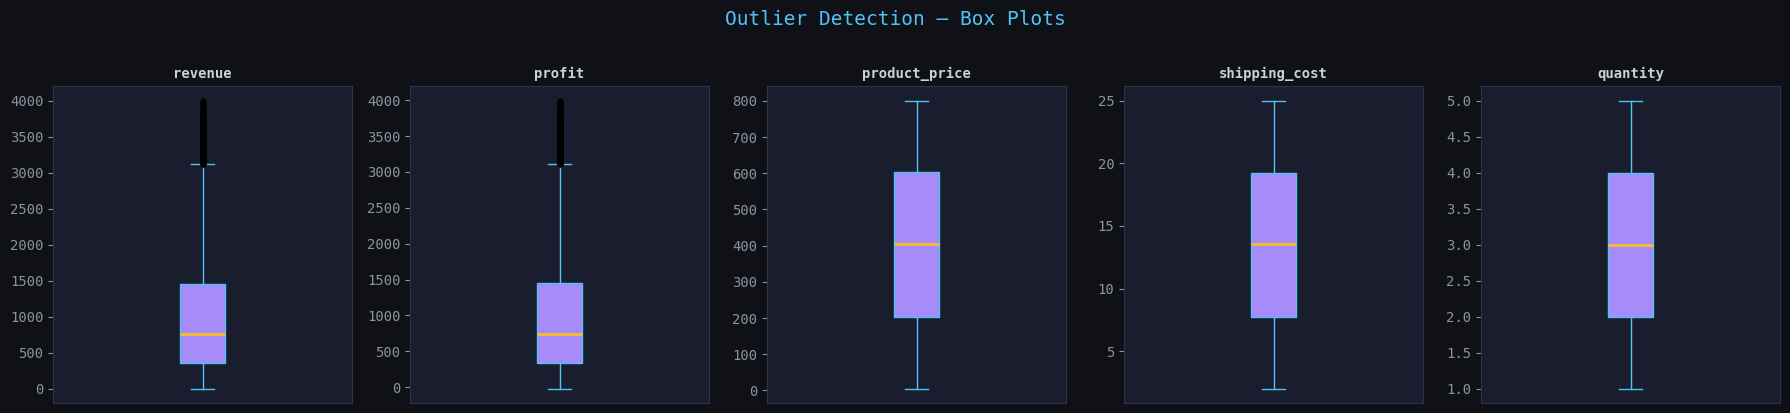

In [9]:
# ── IQR-based outlier flagging for key numeric columns ─────────────
def flag_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return (series < lower) | (series > upper)

numeric_check = ['revenue','profit','product_price','shipping_cost','quantity']
outlier_report = {}
for col in numeric_check:
    mask = flag_outliers(df[col])
    outlier_report[col] = {'outlier_count': mask.sum(),
                           'outlier_pct': round(mask.mean()*100,2)}

out_df = pd.DataFrame(outlier_report).T
print("OUTLIER REPORT (IQR method)")
print("=" * 40)
print(out_df.to_string())

# Visualise
fig, axes = plt.subplots(1, len(numeric_check), figsize=(18, 4))
fig.suptitle("Outlier Detection — Box Plots", fontsize=14, color=ACCENT, y=1.02)
for ax, col in zip(axes, numeric_check):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=ACCENT2, color=ACCENT),
               medianprops=dict(color=YELLOW, linewidth=2),
               whiskerprops=dict(color=ACCENT),
               capprops=dict(color=ACCENT),
               flierprops=dict(marker='o', color=RED, alpha=0.4, markersize=3))
    ax.set_title(col, fontsize=10)
    ax.set_xticks([])
plt.tight_layout()
plt.show()

## 8. Categorical Value Audit

In [10]:
# ── Inspect all categorical columns ───────────────────────────────
cat_cols = ['product_category','customer_country','traffic_source','payment_method']
for col in cat_cols:
    counts = df[col].value_counts()
    print(f"\n{'─'*40}")
    print(f"  {col.upper()}  ({df[col].nunique()} unique values)")
    print(f"{'─'*40}")
    print(counts.to_string())


────────────────────────────────────────
  PRODUCT_CATEGORY  (7 unique values)
────────────────────────────────────────
product_category
Electronics    8624
Accessories    8617
Home Decor     8600
Fashion        8594
Beauty         8586
Sports         8522
Footwear       8457

────────────────────────────────────────
  CUSTOMER_COUNTRY  (7 unique values)
────────────────────────────────────────
customer_country
Australia    8714
Germany      8606
UAE          8599
Canada       8586
India        8554
UK           8472
USA          8469

────────────────────────────────────────
  TRAFFIC_SOURCE  (5 unique values)
────────────────────────────────────────
traffic_source
Organic         12075
Social Media    12024
Paid Ads        12018
Direct          11961
Email           11922

────────────────────────────────────────
  PAYMENT_METHOD  (5 unique values)
────────────────────────────────────────
payment_method
Apple Pay           12116
Cash on Delivery    12032
Credit Card         11998
De

## 9. Data Quality Report — Summary

In [11]:
# ── Final quality scorecard ────────────────────────────────────────
print("=" * 60)
print("   FINAL DATA QUALITY REPORT")
print("=" * 60)
checks = {
    "Total records"          : f"{len(df):,}",
    "Date range"             : f"{df['order_date'].min().date()} → {df['order_date'].max().date()}",
    "Null values remaining"  : df.isna().sum().sum(),
    "Duplicate order_ids"    : df.duplicated(subset=['order_id']).sum(),
    "Revenue mismatches"     : df['revenue_mismatch'].sum(),
    "Price mismatches"       : df['dp_mismatch'].sum(),
    "Unique customers"       : df['customer_id'].nunique(),
    "Unique products"        : df['product_id'].nunique(),
    "Product categories"     : df['product_category'].nunique(),
    "Countries"              : df['customer_country'].nunique(),
    "Traffic sources"        : df['traffic_source'].nunique(),
    "Payment methods"        : df['payment_method'].nunique(),
    "Return rate"            : f"{df['is_returned'].mean()*100:.2f}%",
    "Avg discount %"         : f"{df['discount_percent'].mean():.2f}%",
}
for k, v in checks.items():
    status = "✅" if v not in [0, "0"] else "⚠️ "
    print(f"  {status}  {k:<30} {v}")
print("=" * 60)
print("\nGRAIN DEFINITION: fact_sales → one row per order_id")
print("Each order contains exactly one product line item.")

   FINAL DATA QUALITY REPORT
  ✅  Total records                  60,000
  ✅  Date range                     2023-01-01 → 2025-06-18
  ⚠️   Null values remaining          0
  ⚠️   Duplicate order_ids            0
  ⚠️   Revenue mismatches             0
  ⚠️   Price mismatches               0
  ✅  Unique customers               31154
  ✅  Unique products                6998
  ✅  Product categories             7
  ✅  Countries                      7
  ✅  Traffic sources                5
  ✅  Payment methods                5
  ✅  Return rate                    14.81%
  ✅  Avg discount %                 18.15%

GRAIN DEFINITION: fact_sales → one row per order_id
Each order contains exactly one product line item.


## 10. Save Cleaned Dataset

In [12]:
# ── Export cleaned file for downstream notebooks ──────────────────
clean_cols = [c for c in df.columns if c not in
              ['revenue_check','revenue_mismatch','dp_check','dp_mismatch']]
df[clean_cols].to_csv('shopify_cleaned.csv', index=False)
print("✅ Saved: shopify_cleaned.csv")
print(f"   Shape: {df[clean_cols].shape}")

✅ Saved: shopify_cleaned.csv
   Shape: (60000, 21)
